# 02 · Baselines (from scratch)
Report section: *Baseline methods* + part of *Results*. LDA, QDA, kNN + naive baselines on the leakage-safe split, mean +/- std over 3 symmetrization seeds. Results saved to `report/results_baselines.csv` for the consolidated comparison in `04_results`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.baselines import GaussianClassifier, KNNClassifier, MajorityClassifier
from src.metrics import (accuracy, precision_recall_f1, log_loss, confusion_matrix,
                         collapse_winner, collapse_method, summarize_over_seeds)
from src.plotting import plot_confusion_matrix, save_fig

## 1. Baseline panel, seed-averaged (D1)
Each model trains on the symmetrized train and is scored on the original-corner test (same fights as the always-red / market references). QDA is regularized (reg=1.0) - unregularized it is ill-conditioned in ~114 dims. We collapse the 6-class prediction to winner (Red/Blue) and method (KO/SUB/DEC) for readable, reference-comparable numbers.

In [2]:
SEEDS = [0, 1, 2]
specs = {'LDA': lambda: GaussianClassifier('lda'),
         'QDA': lambda: GaussianClassifier('qda', reg=1.0),
         'kNN (k=15)': lambda: KNNClassifier(k=15),
         'majority': lambda: MajorityClassifier()}
acc6, winacc, metacc, ll = ({n: [] for n in specs} for _ in range(4))
always_red = []
for s in SEEDS:
    ds = build_dataset(seed=s)
    Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
    for n, make in specs.items():
        m = make().fit(Xtr, ytr)
        proba = m.predict_proba(Xte)
        pred = m.classes_[proba.argmax(1)]
        acc6[n].append(accuracy(yte, pred))
        winacc[n].append(accuracy(collapse_winner(yte), collapse_winner(pred)))
        metacc[n].append(accuracy(collapse_method(yte), collapse_method(pred)))
        ll[n].append(log_loss(yte, proba, classes=m.classes_))
    always_red.append((collapse_winner(yte) == 'Red').mean())
rows = []
for n in specs:
    a_m, a_s = summarize_over_seeds(acc6[n]); w_m, w_s = summarize_over_seeds(winacc[n])
    me_m, me_s = summarize_over_seeds(metacc[n]); l_m, l_s = summarize_over_seeds(ll[n])
    rows.append({'model': n, 'acc6_mean': a_m, 'acc6_std': a_s, 'winner_mean': w_m,
                 'winner_std': w_s, 'method_mean': me_m, 'logloss_mean': l_m})
res = pd.DataFrame(rows).set_index('model').round(3)
res.to_csv('../report/results_baselines.csv')
print(f'always-red (winner): {np.mean(always_red):.3f}  | coin-flip: 0.500')
res

always-red (winner): 0.562  | coin-flip: 0.500


,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,logloss_mean
model,,,,,,
LDA,0.343,0.004,0.626,0.004,0.516,1.592
QDA,0.230,0.018,0.567,0.029,0.371,3.134
kNN (k=15),0.282,0.004,0.550,0.006,0.497,3.642
majority,0.266,0.025,0.521,0.059,0.514,1.702


## 2. Confusion matrix (best baseline, single seed)

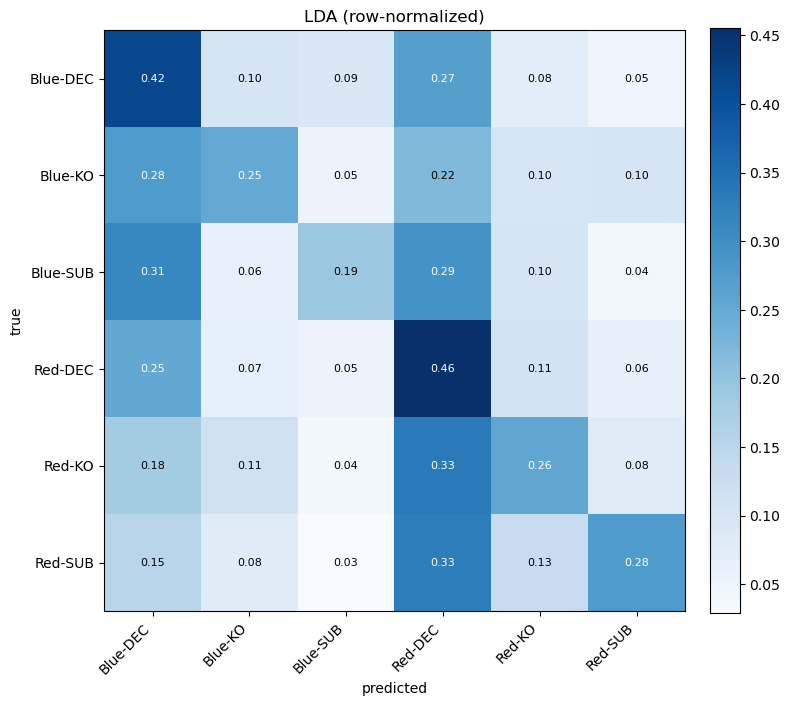

In [3]:
ds = build_dataset(seed=0)
Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
lda = GaussianClassifier('lda').fit(Xtr, ytr)
M, classes = confusion_matrix(yte, lda.predict(Xte), classes=lda.classes_)
plot_confusion_matrix(M, classes, normalize=True); plt.title('LDA (row-normalized)')
save_fig('confusion_matrix_baseline'); plt.show()